In [1]:
import numpy as np
import matplotlib.pyplot as plt
from NO_utilities import encode_eigenfrequency_uniform, decode_eigenfrequency_uniform


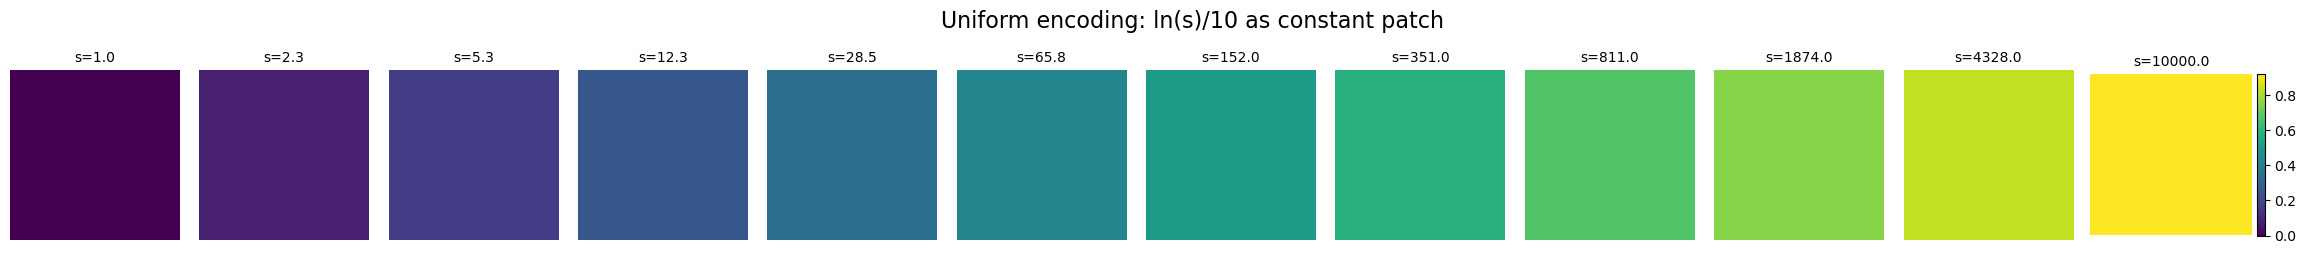

w_original   pixel_value     w_decoded        w_error_%
-------------------------------------------------------
      1.00       0.00000       1.00000         +0.00000%
      2.31       0.08374       2.31055         +0.00000%
      5.34       0.16748       5.33594         +0.00000%
     12.33       0.25122      12.32812         +0.00000%
     28.48       0.33496      28.48438         +0.00000%
     65.81       0.41870      65.87500         +0.09497%
    152.00       0.50244     151.87500         -0.08228%
    351.00       0.58594     350.50000         -0.14246%
    811.00       0.66992     812.00000         +0.12329%
   1874.00       0.75342    1873.00000         -0.05334%
   4328.00       0.83740    4336.00000         +0.18481%
  10000.00       0.92090   10008.00000         +0.08002%


In [2]:
# === Test: 12 log-spaced s values from 1 to 10000 (float16) ===
s_values = np.logspace(0, np.log10(10000), 12, dtype=np.float16)

uniform_images = []
for s in s_values:
    img = encode_eigenfrequency_uniform(s)
    uniform_images.append(img)

# Find the global min/max for color scale for all images
all_images = np.array(uniform_images)
vmin = np.min(all_images)
vmax = np.max(all_images)

fig, axes = plt.subplots(1, 12, figsize=(24, 2.5))  # Single row

# Image artists for colorbar
im_handles = []

for i in range(12):
    img = uniform_images[i]
    im0 = axes[i].imshow(img, cmap="viridis", vmin=vmin, vmax=vmax)
    axes[i].axis("off")
    axes[i].set_title(f"s={float(s_values[i]):.1f}", fontsize=10)
    if i == 0:
        im_handles.append(im0)

axes[0].set_ylabel("Spatial", fontsize=12)
plt.suptitle("Uniform encoding: ln(s)/10 as constant patch", fontsize=16)

# Add a single colorbar to the right, linked to all images
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(axes[-1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cb = fig.colorbar(im_handles[0], cax=cax)
cb.ax.tick_params(labelsize=10)

plt.tight_layout(rect=[0, 0, 0.97, 0.95])
plt.show()

header = f"{'w_original':>10s}  {'pixel_value':>12s}  {'w_decoded':>12s}  {'w_error_%':>15s}"
print(header)
print("-" * len(header))

for i, w in enumerate(s_values):
    img = uniform_images[i]
    w_decoded = np.float16(decode_eigenfrequency_uniform(img))
    pixel_value = img[0, 0]
    w_error_percent = ((w_decoded - w) / w * np.float16(100)).astype(np.float16)
    print(f"{float(w):10.2f}  {float(pixel_value):12.5f}  {float(w_decoded):12.5f}  {float(w_error_percent):+15.5f}%")


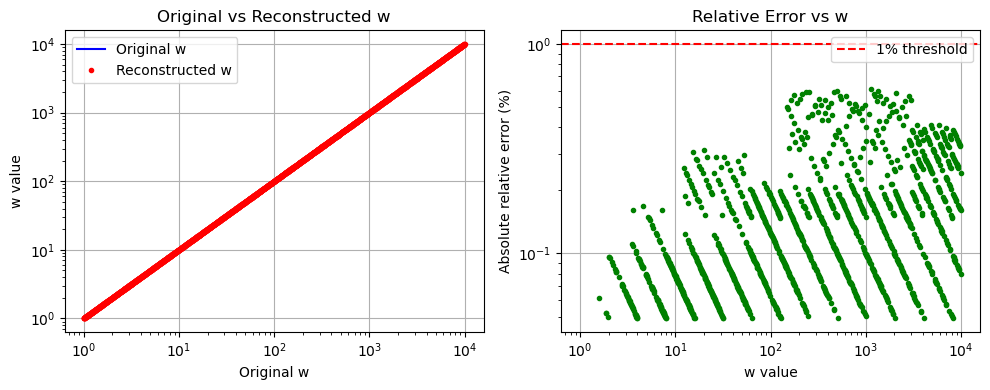

Reconstruction error over 2000 log-spaced w values [1, 10000]:
  Mean |error|:   0.1072 %
  Max |error|:    0.6104 %
  Fraction under 1%:  100.0 %


: 

In [ ]:
# === Dense encode-decode test (float16 only in arrays, using w instead of s) ===
n_test = 2000
w_original = np.logspace(0, np.log10(10000), n_test, dtype=np.float16)
w_reconstructed = np.empty(n_test, dtype=np.float16)

for i, w in enumerate(w_original):
    w_reconstructed[i] = np.float16(decode_eigenfrequency_uniform(encode_eigenfrequency_uniform(w)))

rel_error = ((w_reconstructed - w_original) / w_original * np.float16(100)).astype(np.float16)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(w_original, w_original, "b-", label="Original w")
ax1.plot(w_original, w_reconstructed, "r.", label="Reconstructed w")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("Original w")
ax1.set_ylabel("w value")
ax1.set_title("Original vs Reconstructed w")
ax1.legend()
ax1.grid(True)

abs_err = np.abs(rel_error).astype(np.float16)
ax2.plot(w_original, abs_err, "g.")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("w value")
ax2.set_ylabel("Absolute relative error (%)")
ax2.set_title("Relative Error vs w")
ax2.grid(True)
ax2.axhline(y=np.float16(1), color="r", linestyle="--", label="1% threshold")
ax2.legend()

plt.tight_layout()
plt.show()

mean_abs = np.sum(abs_err, dtype=np.float16) / np.float16(n_test)
max_abs = np.max(abs_err)
frac_under = np.float16(np.count_nonzero(abs_err < np.float16(1))) / np.float16(n_test) * np.float16(100)
print(f"Reconstruction error over {n_test} log-spaced w values [1, 10000]:")
print(f"  Mean |error|:   {float(mean_abs):.4f} %")
print(f"  Max |error|:    {float(max_abs):.4f} %")
print(f"  Fraction under 1%:  {float(frac_under):.1f} %")
